# Pós-hoc: métricas de um run

Métricas calculadas depois do treino, a partir dos artefatos. O pipeline mede
apenas acurácia; tudo aqui sai das predições e probabilidades exportadas, sem
retreinar.

In [1]:
RAIZ <- "../../results/_smoke"
RUN <- "latest"

suppressMessages(devtools::load_all("../../analysis", quiet = TRUE))
suppressMessages({
  library(ggplot2)
  library(dplyr)
  library(tidyr)
})
options(repr.plot.width = 9, repr.plot.height = 4.5)

run <- read_run(RUN, RAIZ)
m <- run$manifest
sel <- m$selected_arm

## O run

In [2]:
data.frame(
  campo = c("run", "modelo", "dataset", "seeds", "orçamento", "arm selecionado", "classes"),
  valor = c(
    run$run_id, m$model,
    if (nzchar(m$subset)) paste0(m$dataset, "/", m$subset) else m$dataset,
    m$n_seeds, m$budget, m$selected_label, m$num_classes
  )
)

campo,valor
<chr>,<chr>
run,cnn-medmnist-2026-08-18_14-08-34
modelo,cnn
dataset,medmnist/breastmnist
seeds,2
orçamento,smoke
arm selecionado,melhor config (Optuna)
classes,2


In [3]:
cat("artefatos disponíveis:\n")
for (a in c("seed_metrics", "predictions", "epochs", "probabilities", "trials")) {
  cat(sprintf("  %-14s %s\n", a, if (is.null(run[[a]])) "ausente" else paste(nrow(run[[a]]), "linhas")))
}

artefatos disponíveis:


  seed_metrics   8 linhas
  predictions    936 linhas
  epochs         8 linhas
  probabilities  1872 linhas
  trials         4 linhas


## Curvas de aprendizado

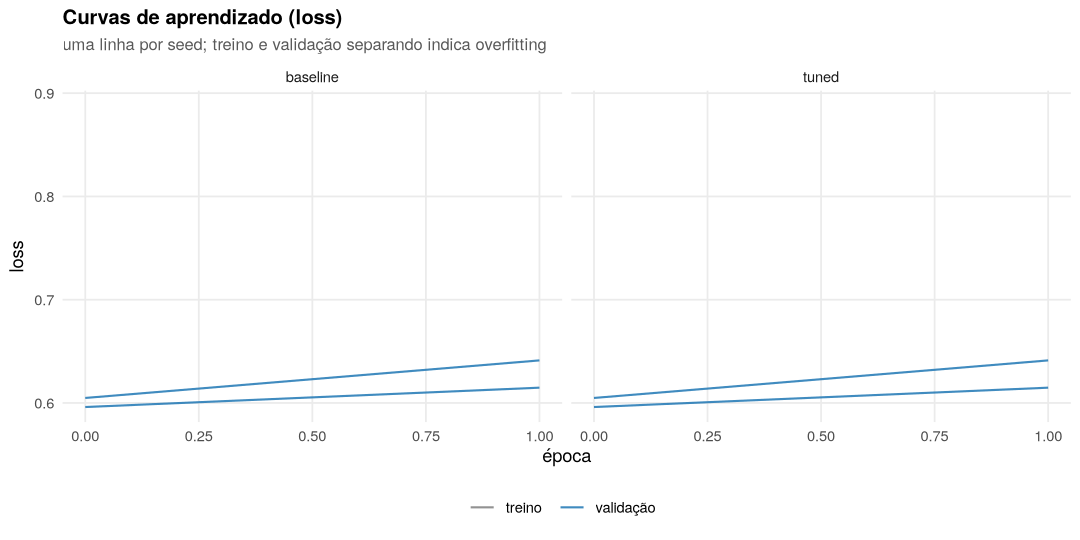

In [4]:
if (is.null(run$epochs)) {
  cat("epochs.csv ausente: run exportado antes desse artefato existir.\n")
} else {
  print(plot_learning_curves(run$epochs, "loss"))
}

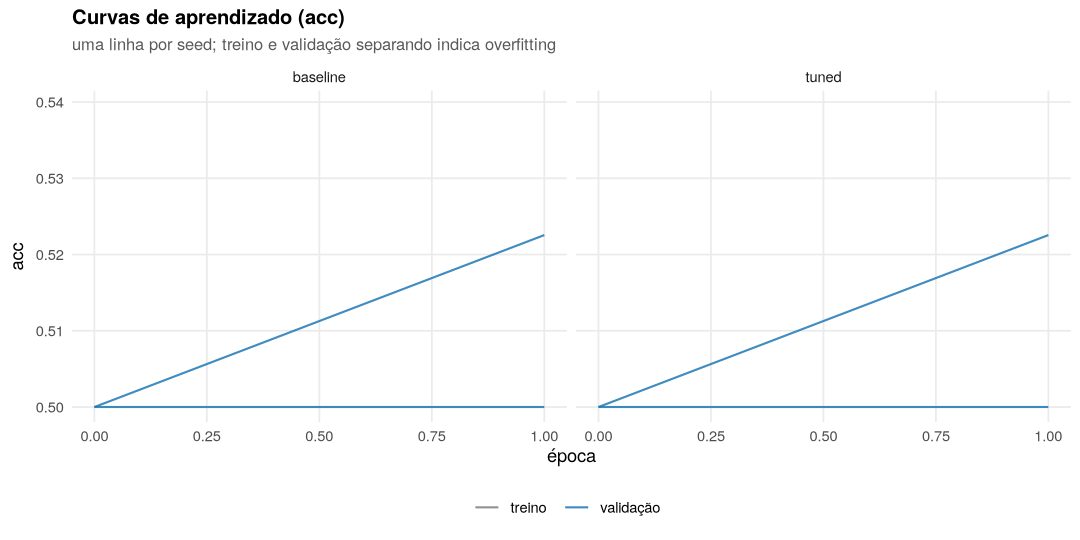

In [5]:
if (!is.null(run$epochs)) print(plot_learning_curves(run$epochs, "acc"))

## Métricas agregadas por arm

In [6]:
met <- run_metrics(run) |> filter(split == "test")
met |>
  group_by(arm) |>
  summarise(across(c(accuracy, balanced_accuracy, f1_macro, f1_weighted), mean), .groups = "drop") |>
  as.data.frame()

arm,accuracy,balanced_accuracy,f1_macro,f1_weighted
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
baseline,0.7147436,0.4965539,0.4356998,0.6186925
tuned,0.7147436,0.4965539,0.4356998,0.6186925


In [7]:
g <- met |>
  group_by(arm) |>
  summarise(gap = mean(accuracy) - mean(balanced_accuracy), .groups = "drop")
print(as.data.frame(g))

if (any(g$gap > 0.05)) {
  cat(sprintf("\n→ diferença de até %.1f pp entre acurácia e balanced accuracy.\n", 100 * max(g$gap)))
  cat("  O modelo acerta a classe majoritária e falha nas raras. Reporte balanced accuracy.\n")
} else {
  cat("\n→ acurácia e balanced accuracy próximas; a acurácia é interpretável aqui.\n")
}

       arm       gap
1 baseline 0.2181897
2    tuned 0.2181897



→ diferença de até 21.8 pp entre acurácia e balanced accuracy.
  O modelo acerta a classe majoritária e falha nas raras. Reporte balanced accuracy.


## Variação entre seeds

O desvio entre seeds é a régua para julgar a diferença entre arms. Ganho menor
que o desvio da própria configuração é ruído de inicialização.

In [8]:
met |>
  select(arm, seed_init, accuracy, balanced_accuracy, f1_macro) |>
  arrange(arm, seed_init) |>
  as.data.frame()

arm,seed_init,accuracy,balanced_accuracy,f1_macro
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
baseline,42,0.7307692,0.5000000,0.4222222
baseline,43,0.6987179,0.4931078,0.4491774
tuned,42,0.7307692,0.5000000,0.4222222
tuned,43,0.6987179,0.4931078,0.4491774


In [9]:
met |>
  group_by(arm) |>
  summarise(
    across(c(accuracy, balanced_accuracy, f1_macro), list(media = mean, dp = sd)),
    .groups = "drop"
  ) |>
  as.data.frame()

arm,accuracy_media,accuracy_dp,balanced_accuracy_media,balanced_accuracy_dp,f1_macro_media,f1_macro_dp
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
baseline,0.7147436,0.02266368,0.4965539,0.004873543,0.4356998,0.01906017
tuned,0.7147436,0.02266368,0.4965539,0.004873543,0.4356998,0.01906017


O desvio entre seeds é a régua para julgar a diferença entre arms. Um ganho menor
que o desvio da própria configuração não é ganho, é ruído de inicialização.

## AUC

In [10]:
if (is.null(run$probabilities)) {
  cat("probabilities.csv.gz ausente: sem ele não há AUC nem calibração.\n")
} else {
  truth <- truth_of(run, "test")
  auc_por_arm <- lapply(c("baseline", "tuned"), function(a) {
    res <- auc_macro_ovr(probs_of(run, a, "test"), truth)
    data.frame(arm = a, auc_macro = res$macro)
  }) |> bind_rows()
  print(as.data.frame(auc_por_arm))
}

       arm auc_macro
1 baseline 0.4342105
2    tuned 0.4342105


In [11]:
if (!is.null(run$probabilities)) {
  res <- auc_macro_ovr(probs_of(run, sel, "test"), truth_of(run, "test"))
  res$per_class |>
    mutate(classe = m$class_names[class_idx + 1L]) |>
    select(classe, n_pos, auc) |>
    arrange(auc) |>
    as.data.frame()
}

classe,n_pos,auc
<chr>,<int>,<dbl>
malignant,42,0.4342105
"normal, benign",114,0.4342105


AUC é a métrica que o benchmark oficial do MedMNIST reporta junto da acurácia, e
é a que não se deixa enganar por desbalanço: ela mede ordenação, não o acerto no
limiar de 0,5. Uma AUC abaixo de 0,5 indica que o escore está ordenando ao
contrário, o que num run curto significa que o modelo ainda não aprendeu nada
útil.

## Calibração

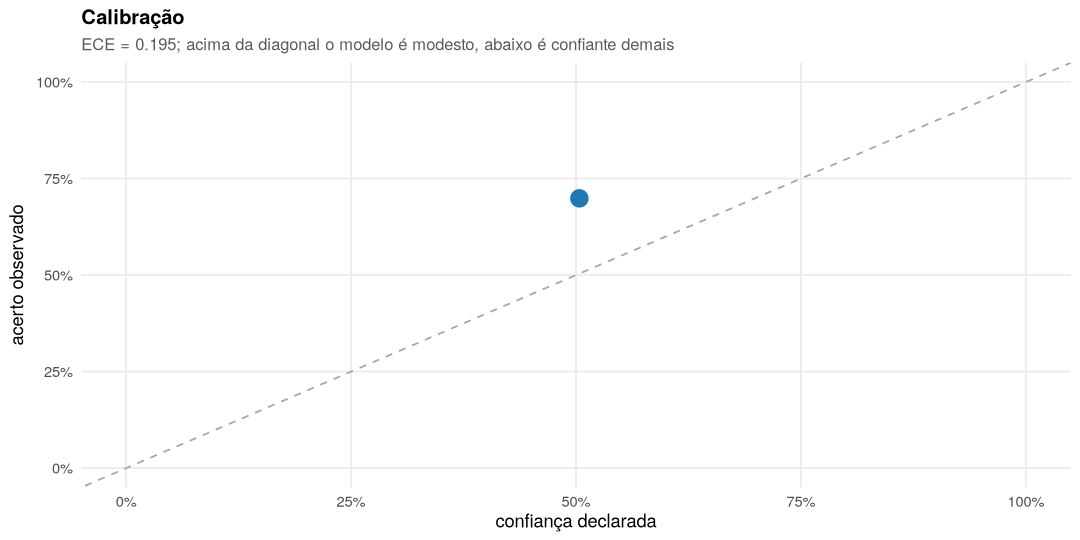

In [12]:
if (!is.null(run$probabilities)) {
  ct <- confidence_table(run, sel, "test")
  cal <- calibration_bins(ct$correct, ct$confidence, bins = 10)
  print(plot_calibration(cal))
}

In [13]:
if (!is.null(run$probabilities)) {
  cat(sprintf("ECE: %.4f\n", cal$ece))
  cat(sprintf("confiança média: %.1f%% | acerto observado: %.1f%%\n",
              100 * mean(ct$confidence), 100 * mean(ct$correct)))
  cat(if (mean(ct$confidence) > mean(ct$correct)) {
    "→ confiante demais: declara mais certeza do que acerta.\n"
  } else {
    "→ modesto: acerta mais do que declara.\n"
  })
  print(as.data.frame(cal$bins))
}

ECE: 0.1950
confiança média: 50.4% | acerto observado: 69.9%
→ modesto: acerta mais do que declara.
      faixa   n conf_media    acerto
1 (0.5,0.6] 156  0.5037353 0.6987179


Acurácia e calibração são independentes. Um modelo pode acertar 90% e dizer "99%
de certeza" em tudo, o que o torna inútil para qualquer decisão que dependa do
limiar. Em domínio médico, onde a probabilidade alimenta encaminhamento, isso
importa mais que o ponto de acurácia.

## ROC

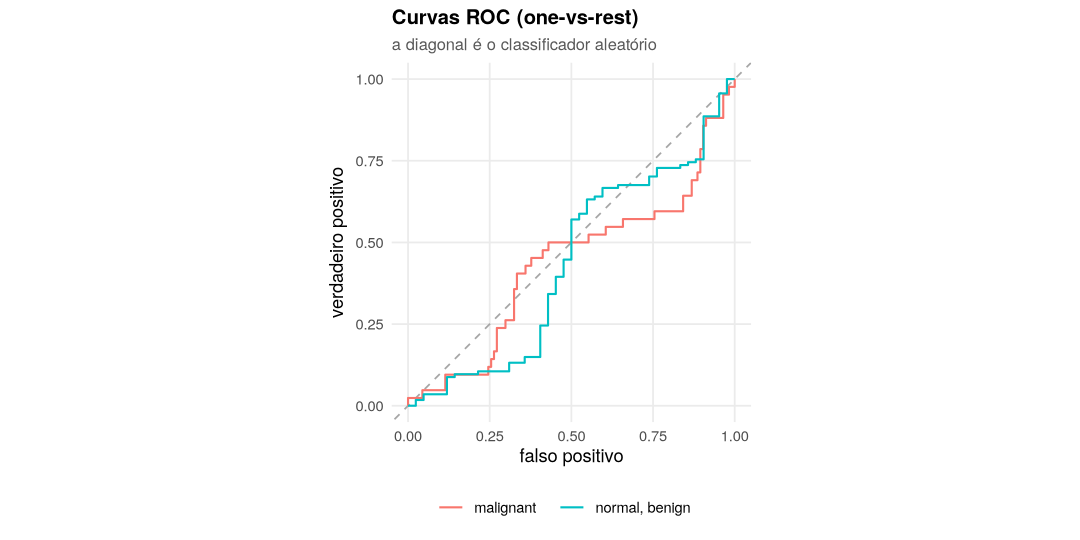

In [14]:
if (!is.null(run$probabilities)) {
  print(plot_roc(probs_of(run, sel, "test"), truth_of(run, "test"), m$class_names))
}

## A validação prediz o teste?

Se a ordem dos arms mudar entre validação e teste, a métrica de seleção não está
predizendo o que interessa.

In [15]:
run_metrics(run) |>
  group_by(arm, split) |>
  summarise(accuracy = mean(accuracy), balanced = mean(balanced_accuracy), .groups = "drop") |>
  pivot_wider(names_from = split, values_from = c(accuracy, balanced)) |>
  as.data.frame()

arm,accuracy_test,accuracy_val,balanced_test,balanced_val
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
baseline,0.7147436,0.7371795,0.4965539,0.5194236
tuned,0.7147436,0.7371795,0.4965539,0.5194236


A seleção do modelo acontece na validação. Se a ordem dos arms mudar entre
validação e teste, a métrica de seleção não está predizendo o que interessa, e o
guard-rail de fallback para a baseline existe justamente para limitar o dano.

## O que fica

In [16]:
cat(sprintf("- arm selecionado: %s\n", m$selected_label))
best <- filter(met, arm == sel)
cat(sprintf("- acurácia %.2f%% | balanced %.2f%% | F1 macro %.2f%%\n",
            100 * mean(best$accuracy), 100 * mean(best$balanced_accuracy), 100 * mean(best$f1_macro)))
if (!is.null(run$probabilities)) {
  cat(sprintf("- AUC macro %.4f | ECE %.4f\n", res$macro, cal$ece))
}
cat("- nenhuma dessas métricas exigiu retreinar\n")

- arm selecionado: melhor config (Optuna)


- acurácia 71.47% | balanced 49.66% | F1 macro 43.57%


- AUC macro 0.4342 | ECE 0.1950


- nenhuma dessas métricas exigiu retreinar
